<a href="https://colab.research.google.com/github/efrat-dev/insider-threat-detector/blob/main/01_lstm_encoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# LSTM Autoencoder — V1 simple + V2 improved

# imports

In [ ]:
# Imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import gdown

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import (
    precision_score, recall_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

# Seed

In [ ]:
# Threading and seeds
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Helper utilities

In [ ]:
def reset_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def train_lstm_model(model, X_train, X_val, checkpoint_path, epochs, batch_size, patience=5):
    early_stop = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    checkpoint = ModelCheckpoint(
        checkpoint_path, save_best_only=True, monitor='val_loss', save_weights_only=False
    )
    history = model.fit(
        X_train, X_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, X_val),
        callbacks=[early_stop, checkpoint],
        verbose=1
    )
    best_model = load_model(checkpoint_path)
    return history, best_model

def plot_loss(history, title='Training & Validation Loss Over Epochs'):
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Data preparation

### Simple LSTM input (V1)

In [ ]:
def prepare_lstm_input(csv_path, exclude_malicious=True, max_length=None, min_days=30):
    """
    V1: chronological sequences per employee, pad all to same length.
    Uses *_zscore features excluding static/identity features.
    """
    df = pd.read_csv(csv_path)

    if exclude_malicious and 'is_malicious' in df.columns:
        df = df[df['is_malicious'] == 0]

    exclude_keywords = [
        'employee_department', 'employee_position', 'employee_classification_freq',
        'employee_campus_cat', 'has_criminal_record', 'has_medical_history',
        'has_foreign_citizenship', 'is_contractor', 'is_employee_in_origin_country',
        'employee_seniority', 'is_new_employee', 'is_veteran_employee'
    ]

    feature_cols = [
        col for col in df.columns
        if col.endswith('_zscore') and not any(key in col for key in exclude_keywords)
    ]

    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    else:
        raise ValueError("Field 'date' not found")

    df_sorted = df.sort_values(by=['employee_id', 'date'])
    X, employee_ids = [], []

    for emp_id, group in df_sorted.groupby('employee_id'):
        group = group[feature_cols].dropna()
        if len(group) >= min_days:
            X.append(group.values)
            employee_ids.append(emp_id)

    if max_length is None:
        max_length = max(len(seq) for seq in X)

    X_padded = np.array([
        np.pad(seq, ((0, max_length - len(seq)), (0, 0)), mode='constant', constant_values=0)
        for seq in X
    ])

    return X_padded, employee_ids, feature_cols, max_length


### Improved LSTM input (V2)

In [ ]:
def prepare_lstm_input_V2(csv_path, exclude_malicious=True, max_length=None, min_days=30):
    """
    V2: like V1 but supports truncation to max_length (take last max_length timesteps).
    """
    df = pd.read_csv(csv_path)

    if exclude_malicious and 'is_malicious' in df.columns:
        df = df[df['is_malicious'] == 0]

    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    else:
        raise ValueError("Field 'date' not found")

    exclude_keywords = [
        'employee_department', 'employee_position', 'employee_classification_freq',
        'employee_campus_cat', 'has_criminal_record', 'has_medical_history',
        'has_foreign_citizenship', 'is_contractor', 'is_employee_in_origin_country',
        'employee_seniority', 'is_new_employee', 'is_veteran_employee'
    ]

    feature_cols = [
        col for col in df.columns
        if col.endswith('_zscore') and not any(key in col for key in exclude_keywords)
    ]

    df_sorted = df.sort_values(by=['employee_id', 'date'])
    X, employee_ids = [], []

    for emp_id, group in df_sorted.groupby('employee_id'):
        group = group[feature_cols].dropna()
        if len(group) >= min_days:
            seq = group.values
            if max_length is not None and len(seq) > max_length:
                seq = seq[-max_length:]  # take last max_length timesteps
            X.append(seq)
            employee_ids.append(emp_id)

    if max_length is None:
        max_length = max(len(seq) for seq in X)

    X_padded = np.array([
        np.pad(seq, ((0, max_length - len(seq)), (0, 0)), mode='constant', constant_values=0)
        for seq in X
    ])

    return X_padded, employee_ids, feature_cols, max_length

# Models

### Simple LSTM Model (V1)

In [ ]:
def build_lstm_autoencoder(input_shape, latent_dim=32):
    """
    V1: simple autoencoder (no dropout), medium bottleneck.
    """
    inputs = Input(shape=input_shape)
    encoded = LSTM(64, activation='tanh', return_sequences=False)(inputs)
    bottleneck = Dense(latent_dim, activation='relu')(encoded)
    repeated = RepeatVector(input_shape[0])(bottleneck)
    decoded = LSTM(64, activation='tanh', return_sequences=True)(repeated)
    outputs = TimeDistributed(Dense(input_shape[1]))(decoded)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

### Improved LSTM Model (V2)

In [ ]:
def build_lstm_autoencoder_v2(input_shape, latent_dim=16, dropout_rate=0.1):
    """
    V2: improved variant with dropout and smaller bottleneck.
    """
    inputs = Input(shape=input_shape)
    x = LSTM(64, activation='tanh', return_sequences=False)(inputs)
    x = Dropout(dropout_rate)(x)
    bottleneck = Dense(latent_dim, activation='relu')(x)
    x = RepeatVector(input_shape[0])(bottleneck)
    x = LSTM(64, activation='tanh', return_sequences=True)(x)
    x = Dropout(dropout_rate)(x)
    outputs = TimeDistributed(Dense(input_shape[1]))(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(), loss='mse')
    return model

# Download from Google Drive

In [ ]:
file_ids = {
    'train_path': '12p0bNMpieaZ6yoPS-BI71QA_oz7t708i',
    'test_path':  '18r_G-VF2mjD3ZsGdKOLKFQ6lO5ptSZ_y',
    'val_path':   '1hShE7wkL0d9BE5AVdKgfV68adyCE_jy5',
}

def download_file(file_id, filename):
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, filename, quiet=False)


# Download the files
download_file(file_ids['train_path'], 'train_processed_lstm.csv')
download_file(file_ids['test_path'],  'test_processed_lstm.csv')
download_file(file_ids['val_path'],   'val_processed_lstm.csv')

# Define the path variables for use in other parts of the code
train_path = 'train_processed_lstm.csv'
test_path = 'test_processed_lstm.csv'
val_path = 'val_processed_lstm.csv'

Downloading...
From (original): https://drive.google.com/uc?id=12p0bNMpieaZ6yoPS-BI71QA_oz7t708i
From (redirected): https://drive.google.com/uc?id=12p0bNMpieaZ6yoPS-BI71QA_oz7t708i&confirm=t&uuid=547bc182-8ba3-4787-a78f-b973a2ed19c8
To: /content/train_processed_lstm.csv
100%|██████████| 396M/396M [00:07<00:00, 50.5MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=18r_G-VF2mjD3ZsGdKOLKFQ6lO5ptSZ_y
From (redirected): https://drive.google.com/uc?id=18r_G-VF2mjD3ZsGdKOLKFQ6lO5ptSZ_y&confirm=t&uuid=f730de94-354a-4b54-9e2b-6682ed794403
To: /content/test_processed_lstm.csv
100%|██████████| 132M/132M [00:05<00:00, 25.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1hShE7wkL0d9BE5AVdKgfV68adyCE_jy5
From (redirected): https://drive.google.com/uc?id=1hShE7wkL0d9BE5AVdKgfV68adyCE_jy5&confirm=t&uuid=45ce10be-ee6b-4752-8806-a73167a3b813
To: /content/val_processed_lstm.csv
100%|██████████| 132M/132M [00:02<00:00, 55.1MB/s]


# Labels builder

In [ ]:
def build_true_labels_per_employee(csv_path, employee_ids, threshold_ratio=0.2):
    df = pd.read_csv(csv_path)
    df['date'] = pd.to_datetime(df['date'])
    malicious_by_employee = df.groupby('employee_id')['is_malicious'].mean()
    malicious_by_employee = malicious_by_employee.loc[employee_ids]
    true_labels = (malicious_by_employee > threshold_ratio).astype(int).values
    return true_labels, malicious_by_employee

# Evaluation Func

### Simple baseline evaluation (V1)

In [ ]:
# Simple baseline evaluation (V1) : mean MSE + fixed TRAIN p97.5 threshold

def mean_mse_per_employee(model, X):
    """
    Compute a single anomaly score per employee:
    mean MSE over all timesteps and features.
    """
    X_pred = model.predict(X, verbose=0)
    return np.mean((X - X_pred) ** 2, axis=(1, 2))

def evaluate_v1_mean_train975thr(best_model_v1,
                                  X_train_v1, X_val_v1, X_test_v1,
                                  train_path, val_path, test_path,
                                  val_employee_ids_v1, test_employee_ids_v1):
    """
    - Score: mean MSE across timesteps & features (per employee).
    - Threshold: fixed, unsupervised — the 97.5th percentile of TRAIN scores.
    - Reports metrics and confusion matrices for VAL & TEST.
    """
    # Scores
    s_train = mean_mse_per_employee(best_model_v1, X_train_v1)
    s_val   = mean_mse_per_employee(best_model_v1, X_val_v1)
    s_test  = mean_mse_per_employee(best_model_v1, X_test_v1)

    # Fixed threshold from TRAIN only (unsupervised)
    thr = float(np.percentile(s_train, 97.5))

    # Employee-level labels (ratio >= 0.2)
    true_val,  _ = build_true_labels_per_employee(val_path,  val_employee_ids_v1,  threshold_ratio=0.2)
    true_test, _ = build_true_labels_per_employee(test_path, test_employee_ids_v1, threshold_ratio=0.2)

    # Predictions
    pred_val  = (s_val  >= thr).astype(int)
    pred_test = (s_test >= thr).astype(int)

    # Reports — VAL
    print(f"[V1 (simple baseline)] === VAL metrics (fixed thr @ p97.5 of TRAIN) ===")
    print(classification_report(true_val, pred_val, target_names=["Benign","Malicious"], digits=3))
    cm_val = confusion_matrix(true_val, pred_val)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=["Benign","Malicious"])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"[V1 baseline] Confusion Matrix — VAL (thr≈{thr:.4f})")
    plt.grid(False); plt.tight_layout(); plt.show()

    # Reports — TEST
    print(f"[V1 (simple baseline)] === TEST metrics (fixed thr from TRAIN p97.5) ===")
    print(classification_report(true_test, pred_test, target_names=["Benign","Malicious"], digits=3))
    cm_test = confusion_matrix(true_test, pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["Benign","Malicious"])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"[V1 baseline] Confusion Matrix — TEST (thr≈{thr:.4f})")
    plt.grid(False); plt.tight_layout(); plt.show()

    # Histograms for transparency
    for name, s in [("TRAIN", s_train), ("VAL", s_val), ("TEST", s_test)]:
        plt.figure(figsize=(8,4.5))
        plt.hist(s, bins=40, alpha=0.6, label=name, density=True)
        plt.axvline(thr, linestyle='--', label=f"Threshold ≈ {thr:.4f}")
        plt.title(f"[V1 baseline] Score distribution — {name} (mean MSE)")
        plt.xlabel("mean MSE (per employee)"); plt.ylabel("density")
        plt.legend(); plt.tight_layout(); plt.show()

    return {"threshold": thr,
            "scores": {"train": s_train, "val": s_val, "test": s_test},
            "preds": {"val": pred_val, "test": pred_test}}

### Improved evaluation (V2)

In [ ]:
# Improved Evaluation (V2): TOP-K + VAL-tuned threshold + CSVs

TOP_K = 3  # use top-3 (balance between simple AVG and MAX)

def topk_mean(arr1d, k=TOP_K):
    k = max(1, min(int(k), len(arr1d)))
    return float(np.mean(np.partition(arr1d, -k)[-k:]))

def compute_reconstruction_errors(model, X, top_k=TOP_K):
    X_pred = model.predict(X)
    per_ts_err = np.mean((X - X_pred) ** 2, axis=2)  # (n_emp, timesteps)
    errors = np.array([topk_mean(row, top_k) for row in per_ts_err])
    return errors

def tune_threshold_on_validation(errors_val, true_labels_val):
    val_threshold_results = []
    percentiles = list(range(80, 100, 1))
    for p in percentiles:
        thr = np.percentile(errors_val, p)
        preds = (errors_val > thr).astype(int)
        precision = precision_score(true_labels_val, preds, zero_division=0)
        recall    = recall_score(true_labels_val, preds, zero_division=0)
        f1        = f1_score(true_labels_val, preds, zero_division=0)
        val_threshold_results.append({
            'Threshold Type': f'Percentile {p}',
            'Threshold Value': float(thr),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1 Score': round(f1, 4)
        })
    for mult in [1.0, 1.5, 2.0, 2.5]:
        thr = np.mean(errors_val) + mult * np.std(errors_val)
        preds = (errors_val > thr).astype(int)
        precision = precision_score(true_labels_val, preds, zero_division=0)
        recall    = recall_score(true_labels_val, preds, zero_division=0)
        f1        = f1_score(true_labels_val, preds, zero_division=0)
        val_threshold_results.append({
            'Threshold Type': f'Mean + {mult}*STD',
            'Threshold Value': float(thr),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1 Score': round(f1, 4)
        })
    df = pd.DataFrame(val_threshold_results)
    best_row = df.loc[df['F1 Score'].idxmax()]
    return df, best_row

def full_evaluation_and_saving(best_autoencoder,
                               X_train, X_val, X_test,
                               train_path, val_path, test_path,
                               employee_ids, val_employee_ids, test_employee_ids,
                               TOP_K=3):
    # TEST errors
    reconstruction_errors = compute_reconstruction_errors(best_autoencoder, X_test, TOP_K)

    print(f"\n=== Reconstruction Error Statistics (TEST, top-{TOP_K} mean) ===")
    print(f"Mean Error: {np.mean(reconstruction_errors):.6f}")
    print(f"Std Error: {np.std(reconstruction_errors):.6f}")
    print(f"Min Error: {np.min(reconstruction_errors):.6f}")
    print(f"Max Error: {np.max(reconstruction_errors):.6f}")
    print(f"Median Error: {np.median(reconstruction_errors):.6f}")

    # Histogram (TEST)
    plt.hist(reconstruction_errors, bins=50, color='skyblue', edgecolor='black')
    plt.xlabel(f"Reconstruction Error (top-{TOP_K} mean)")
    plt.ylabel("Number of Employees")
    plt.title(f"Histogram of Reconstruction Errors (TEST, top-{TOP_K} mean)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Valiation errors + labels
    reconstruction_errors_val = compute_reconstruction_errors(best_autoencoder, X_val, TOP_K)
    true_labels_val, _ = build_true_labels_per_employee(val_path, val_employee_ids, threshold_ratio=0.2)

    # Threshold tuning (VAL)
    df_val_threshold_comparison, best_row_val = tune_threshold_on_validation(reconstruction_errors_val, true_labels_val)
    try:
        from IPython.display import display
        display(df_val_threshold_comparison)
    except:
        print(df_val_threshold_comparison)
    print(f"Chosen threshold (tuned on VALIDATION, top-{TOP_K} mean):\n", best_row_val)
    best_thresh_value = best_row_val['Threshold Value']

    # === EVALUATE ON VALIDATION (using the VAL-tuned threshold) ===
    val_auc = roc_auc_score(true_labels_val, reconstruction_errors_val)
    print(f"\n[VAL] ROC-AUC = {val_auc:.3f}")

    pred_labels_val = (reconstruction_errors_val > best_thresh_value).astype(int)

    print("\n=== Classification Report (VAL, thr tuned on VAL) ===")
    print(classification_report(true_labels_val,
                                pred_labels_val,
                                target_names=["Benign","Malicious"],
                                zero_division=0))

    cm_val = confusion_matrix(true_labels_val, pred_labels_val)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_val,
                                  display_labels=["Benign","Malicious"])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix (VAL, thr={float(best_thresh_value):.4f}, top-{TOP_K} mean)")
    plt.grid(False); plt.tight_layout(); plt.show()


    # TEST labels
    _, malicious_by_employee = build_true_labels_per_employee(test_path, test_employee_ids, threshold_ratio=0.2)
    true_labels = (malicious_by_employee > 0.2).astype(int)

    # ROC (TEST)
    fpr, tpr, _ = roc_curve(true_labels, reconstruction_errors)
    auc = roc_auc_score(true_labels, reconstruction_errors)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title(f'ROC Curve (TEST, top-{TOP_K} mean)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # CM + report
    pred_labels_best = (reconstruction_errors > best_thresh_value).astype(int)

    print(f"\n=== Classification Report (TEST, Threshold tuned on VAL = {best_thresh_value:.6f}) ===")
    print(classification_report(true_labels, pred_labels_best, target_names=["Benign", "Malicious"]))

    cm_best = confusion_matrix(true_labels, pred_labels_best)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["Benign", "Malicious"])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix (TEST, VAL-tuned thr = {best_thresh_value:.4f}, top-{TOP_K} mean)")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    # TRAIN errors (for saving files)
    reconstruction_errors_train = compute_reconstruction_errors(best_autoencoder, X_train, TOP_K)

    # Save files
    os.makedirs("outputs/lstm_v2", exist_ok=True)

    df_train_for_labels = pd.read_csv(train_path)
    df_train_for_labels['date'] = pd.to_datetime(df_train_for_labels['date'])
    malicious_by_employee_train = df_train_for_labels.groupby('employee_id')['is_malicious'].mean()
    malicious_by_employee_train = malicious_by_employee_train.loc[employee_ids]
    true_labels_train = (malicious_by_employee_train > 0.2).astype(int).values

    true_labels_val_series = pd.Series(true_labels_val, index=val_employee_ids)

    df_lstm_score_train = pd.DataFrame({
        'employee_id': employee_ids,
        'lstm_score': reconstruction_errors_train,
        'true_label': true_labels_train
    })
    df_lstm_score_val = pd.DataFrame({
        'employee_id': val_employee_ids,
        'lstm_score': reconstruction_errors_val,
        'true_label': true_labels_val_series.values
    })
    df_lstm_score_test = pd.DataFrame({
        'employee_id': test_employee_ids,
        'lstm_score': reconstruction_errors,
        'true_label': (malicious_by_employee > 0).astype(int).values
    })

    df_lstm_score_train.to_csv("outputs/lstm_v2/lstm_score_per_employee_train.csv", index=False)
    df_lstm_score_val.to_csv(  "outputs/lstm_v2/lstm_score_per_employee_val.csv",   index=False)
    df_lstm_score_test.to_csv( "outputs/lstm_v2/lstm_score_per_employee_test.csv",  index=False)

    df_all_splits = pd.concat([
        df_lstm_score_train.assign(split="train"),
        df_lstm_score_val.assign(split="val"),
        df_lstm_score_test.assign(split="test"),
    ], ignore_index=True)
    df_all_splits = df_all_splits[['employee_id', 'split', 'lstm_score', 'true_label']]

    all_path = "outputs/lstm_v2/lstm_scores_all_splits.csv"
    df_all_splits.to_csv(all_path, index=False)
    print(f"Saved unified scores file: {all_path}")

# Train & Eval

### Train & Eval Simple model (V1)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step - loss: 0.2120 - val_loss: 0.1800
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 0.1797 - val_loss: 0.1783
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.1784 - val_loss: 0.1765
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1760 - val_loss: 0.1726
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1719 - val_loss: 0.1685
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1683 - val_loss: 0.1654
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1655 - val_loss: 0.1637
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1616 - val_loss: 0.1565
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.1569 - val_loss: 0.1557
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1563 - val_loss: 0.1555
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1556 - val_loss: 0.1543
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0

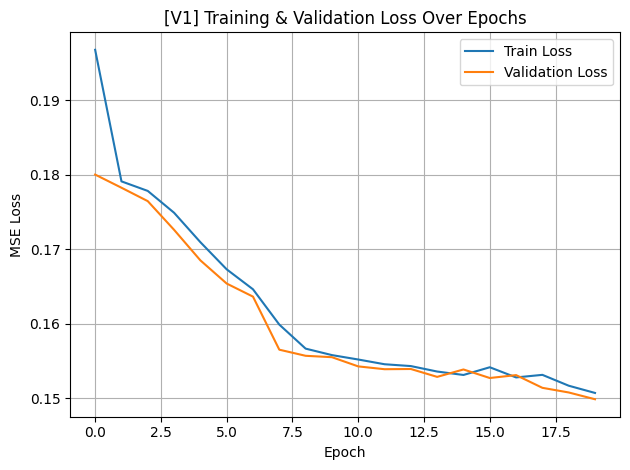

[V1 (simple baseline)] === VAL metrics (fixed thr @ p97.5 of TRAIN) ===
              precision    recall  f1-score   support

      Benign      0.960     0.978     0.969       321
   Malicious      0.000     0.000     0.000        13

    accuracy                          0.940       334
   macro avg      0.480     0.489     0.485       334
weighted avg      0.923     0.940     0.931       334



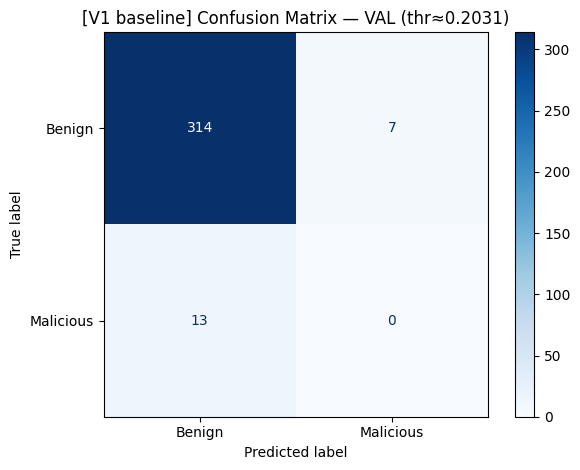

[V1 (simple baseline)] === TEST metrics (fixed thr from TRAIN p97.5) ===
              precision    recall  f1-score   support

      Benign      0.969     0.972     0.970       317
   Malicious      0.438     0.412     0.424        17

    accuracy                          0.943       334
   macro avg      0.703     0.692     0.697       334
weighted avg      0.942     0.943     0.942       334



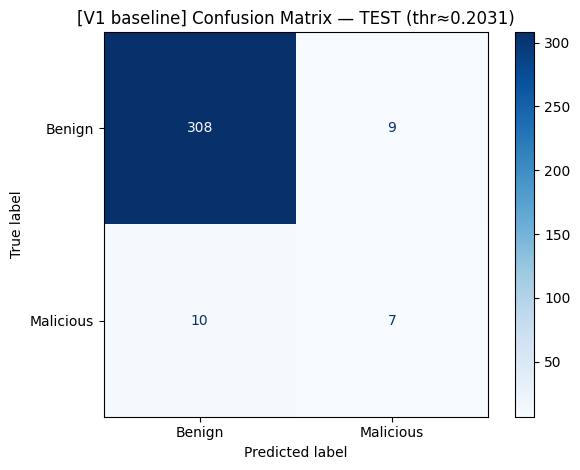

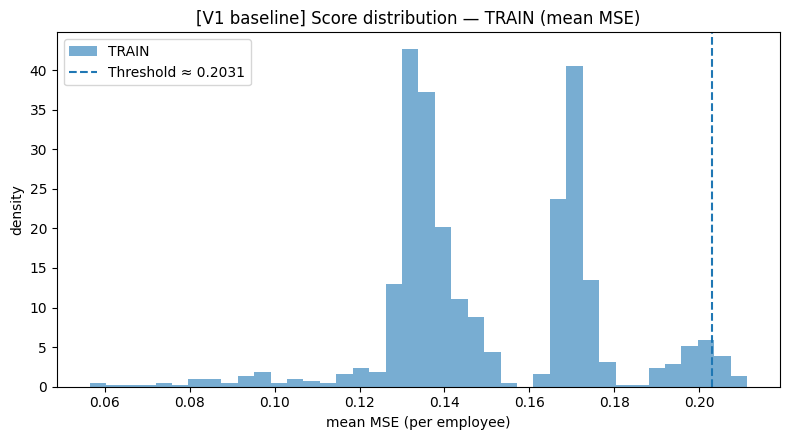

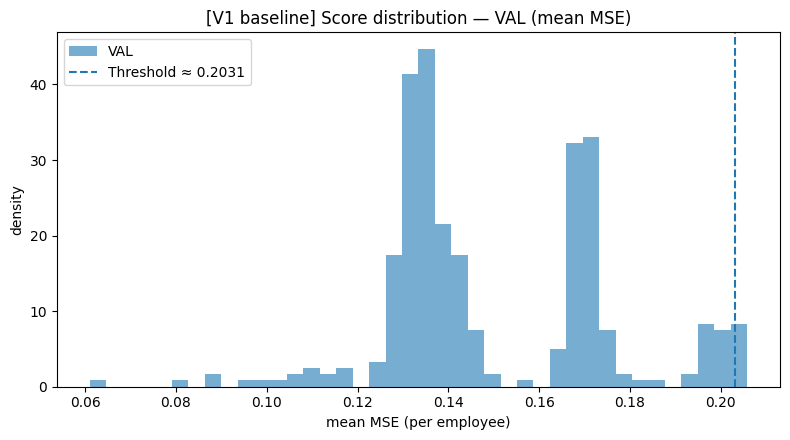

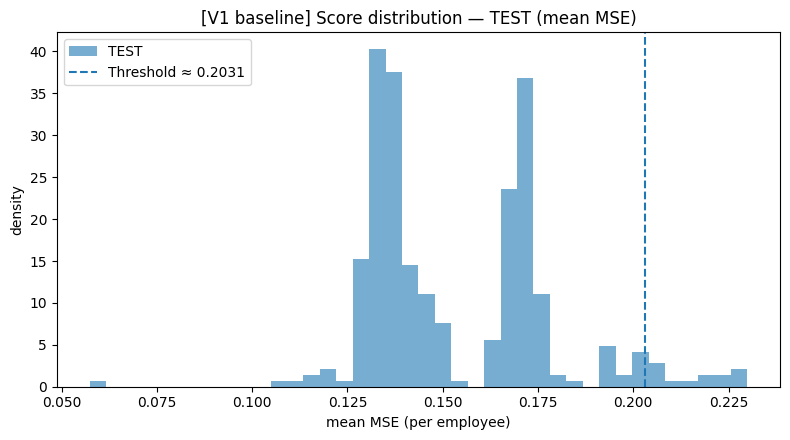

In [ ]:
# Prepare V1 data
X_train_v1, employee_ids_v1, feature_cols_v1, max_len_v1 = prepare_lstm_input(train_path, exclude_malicious=True)
X_val_v1,   val_employee_ids_v1, _, _ = prepare_lstm_input(val_path, exclude_malicious=True, max_length=max_len_v1)
X_test_v1,  test_employee_ids_v1, _, _ = prepare_lstm_input(test_path, exclude_malicious=False, max_length=max_len_v1)

# Build & train V1
input_shape_v1 = (X_train_v1.shape[1], X_train_v1.shape[2])
autoencoder_v1 = build_lstm_autoencoder(input_shape_v1, latent_dim=32)

# Use a separate checkpoint for V1 so it won't affect V2
history_v1, best_model_v1 = train_lstm_model(
    model=autoencoder_v1,
    X_train=X_train_v1,
    X_val=X_val_v1,
    checkpoint_path="best_lstm_v1.keras",
    epochs=20,
    batch_size=32,
    patience=5
)
plot_loss(history_v1, title='[V1] Training & Validation Loss Over Epochs')

# Simple baseline evaluation for V1
_ = evaluate_v1_mean_train975thr(
    best_model_v1,
    X_train_v1, X_val_v1, X_test_v1,
    train_path, val_path, test_path,
    val_employee_ids_v1, test_employee_ids_v1
)

### Train & Eval Improved model (V2)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 60, 46)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        28,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 60, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 60, 46)         │         2,990 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,182 (207.74 KB)

 Trainable params: 53,182 (207.74 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 0.2188 - val_loss: 0.1796
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1823 - val_loss: 0.1683
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1692 - val_loss: 0.1591
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1625 - val_loss: 0.1562
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1599 - val_loss: 0.1552
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1584 - val_loss: 0.1543
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1573 - val_loss: 0.1534
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1564 - val_loss: 0.1528
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1556 - val_loss: 0.1526
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.1551 - val_loss: 0.1519
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1544 - val_loss: 0.1522
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1

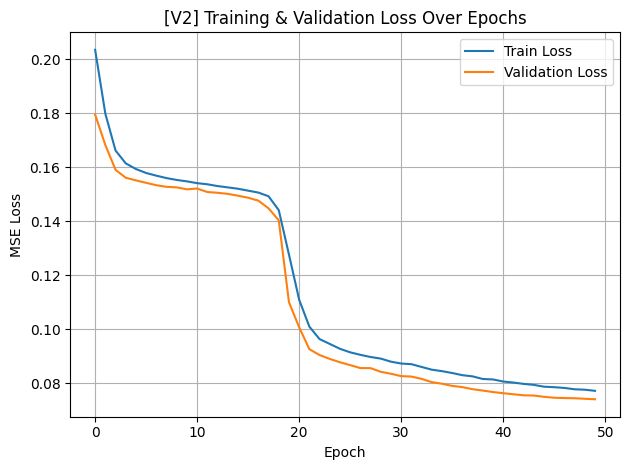

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step

=== Reconstruction Error Statistics (TEST, top-3 mean) ===
Mean Error: 0.317845
Std Error: 0.068823
Min Error: 0.115553
Max Error: 0.588368
Median Error: 0.319239


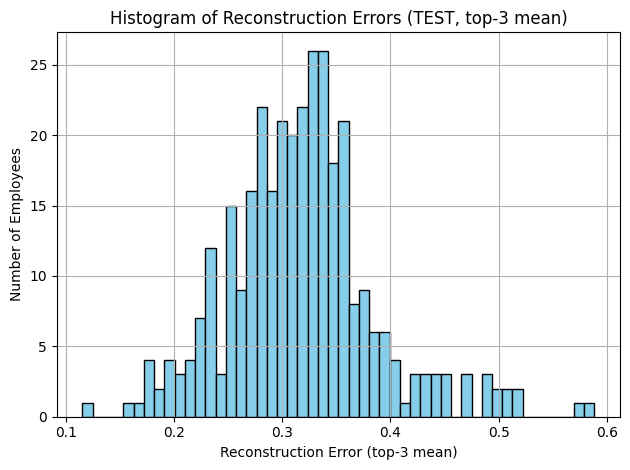

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


,Threshold Type,Threshold Value,Precision,Recall,F1 Score
0,Percentile 80,0.375547,0.1940,1.0000,0.3250
1,Percentile 81,0.379998,0.2031,1.0000,0.3377
2,Percentile 82,0.385577,0.2167,1.0000,0.3562
3,Percentile 83,0.389930,0.2281,1.0000,0.3714
4,Percentile 84,0.391345,0.2407,1.0000,0.3881
5,Percentile 85,0.394032,0.2600,1.0000,0.4127
6,Percentile 86,0.396078,0.2766,1.0000,0.4333
7,Percentile 87,0.400016,0.2955,1.0000,0.4561
8,Percentile 88,0.403982,0.3250,1.0000,0.4906
9,Percentile 89,0.404541,0.3514,1.0000,0.5200


Chosen threshold (tuned on VALIDATION, top-3 mean):
 Threshold Type     Percentile 95
Threshold Value         0.447836
Precision                 0.6471
Recall                    0.8462
F1 Score                  0.7333
Name: 15, dtype: object

[VAL] ROC-AUC = 0.987

=== Classification Report (VAL, thr tuned on VAL) ===
              precision    recall  f1-score   support

      Benign       0.99      0.98      0.99       321
   Malicious       0.65      0.85      0.73        13

    accuracy                           0.98       334
   macro avg       0.82      0.91      0.86       334
weighted avg       0.98      0.98      0.98       334



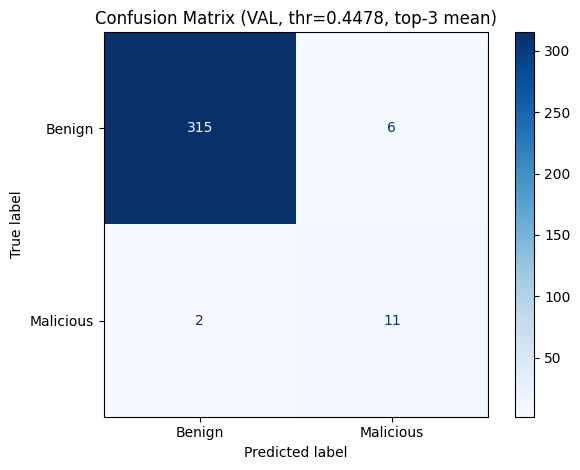

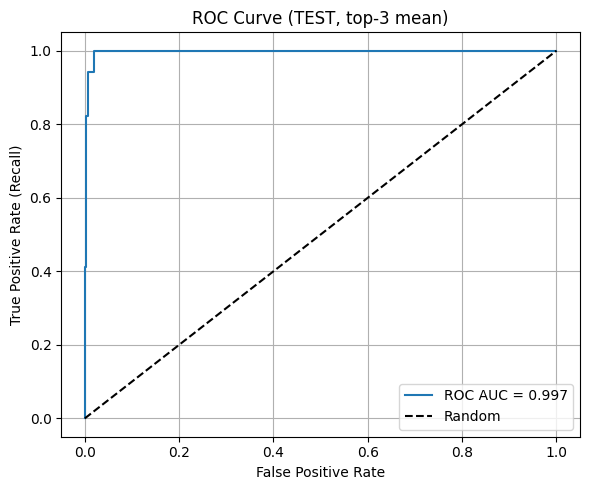


=== Classification Report (TEST, Threshold tuned on VAL = 0.447836) ===
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99       317
   Malicious       0.88      0.82      0.85        17

    accuracy                           0.99       334
   macro avg       0.93      0.91      0.92       334
weighted avg       0.98      0.99      0.98       334



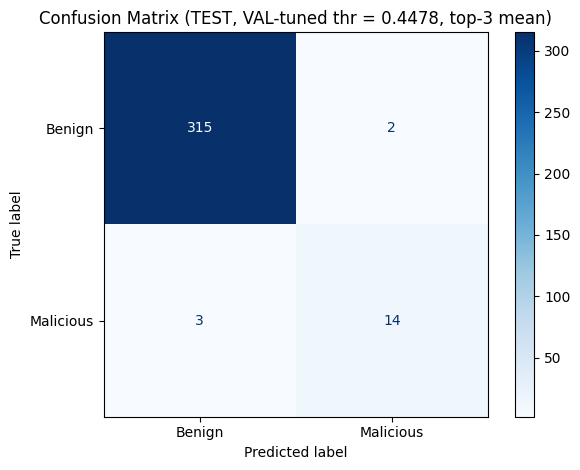

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Saved unified scores file: outputs/lstm_v2/lstm_scores_all_splits.csv


In [ ]:
# Reset RNGs before V2 to keep behavior consistent with the original single-model run
reset_seeds(SEED)

# Prepare V2 data
X_train, employee_ids, feature_cols, max_len = prepare_lstm_input_V2(train_path, exclude_malicious=True, max_length=60)
X_val,   val_employee_ids, _, _ = prepare_lstm_input_V2(val_path, exclude_malicious=True,  max_length=max_len)
X_test,  test_employee_ids, _, _ = prepare_lstm_input_V2(test_path, exclude_malicious=False, max_length=max_len)

# Build & train V2
input_shape = (X_train.shape[1], X_train.shape[2])
autoencoder = build_lstm_autoencoder_v2(input_shape, latent_dim=16, dropout_rate=0.1)
autoencoder.summary()

history, best_autoencoder = train_lstm_model(
    model=autoencoder,
    X_train=X_train,
    X_val=X_val,
    checkpoint_path="best_lstm_model.keras",
    epochs=50,
    batch_size=32,
    patience=5
)
plot_loss(history, title='[V2] Training & Validation Loss Over Epochs')

# Full evaluation & CSV saving
full_evaluation_and_saving(
    best_autoencoder=best_autoencoder,
    X_train=X_train, X_val=X_val, X_test=X_test,
    train_path=train_path, val_path=val_path, test_path=test_path,
    employee_ids=employee_ids, val_employee_ids=val_employee_ids, test_employee_ids=test_employee_ids,
    TOP_K=TOP_K
)
